# Loan Default Prediction

**Dataset:** Loan Default Dataset (Yasserh)  
**Target:** `Status` (1 = default, 0 = no default)

### Workflow
Load → Clean → EDA → Missingness Audit → Ablation Study → Leakage Correction → Preprocessing → Model/Strategy Selection → Threshold Tuning → Final Test Evaluation → Feature Importance → SHAP → Risk Analysis


## Data Dictionary

| Variable | Description |
|---|---|
| ID | client loan application id |
| year | year of loan application |
| loan_limit | conforming or non-conforming |
| Gender | applicant gender |
| approv_in_adv | approved in advance |
| loan_type | type of loan |
| loan_purpose | purpose of loan |
| Credit_Worthiness | credit-worthiness category |
| open_credit | open credit accounts |
| business_or_commercial | business/commercial or personal |
| loan_amount | amount borrowed |
| rate_of_interest | interest rate |
| Interest_rate_spread | rate minus benchmark |
| Upfront_charges | initial charges |
| term | loan duration in months |
| property_value | financed property value |
| income | applicant income |
| Credit_Score | credit score |
| age | applicant age group |
| submission_of_application | application submission type |
| LTV | loan-to-value ratio |
| Region | geographic region |
| Status | **target: 1 = default, 0 = no default** |
| dtir1 | debt-to-income ratio |


## 1. Import Libraries

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, PrecisionRecallDisplay,
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET = "Status"
DATA_PATH = os.path.join("Data", "Loan_Default.csv")


## 2. Load and Clean Data

In [2]:
df = pd.read_csv(DATA_PATH)

# Fix the known spelling error
df["Security_Type"] = df["Security_Type"].replace("Indriect", "Indirect")

print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
display(df.head())


Shape: (148670, 34)
Duplicate rows: 0


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 3. Target Distribution

Target counts:


Status
0    112031
1     36639
Name: count, dtype: int64

Target percentages:


Status
0    75.36
1    24.64
Name: proportion, dtype: float64

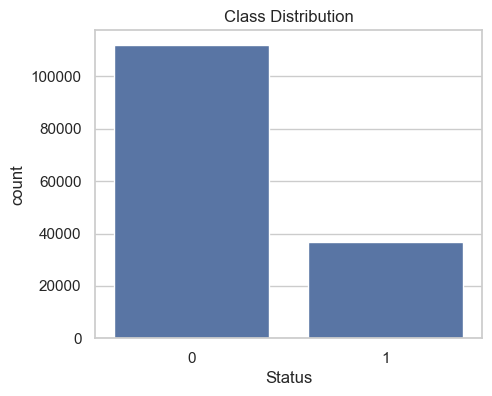

In [3]:
print("Target counts:")
display(df[TARGET].value_counts())

print("Target percentages:")
display((df[TARGET].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x=TARGET, data=df)
plt.title("Class Distribution")
plt.show()


## 4. Remove Non-Predictive Columns

In [4]:
df_model = df.copy()
df_model = df_model.drop(columns=["ID", "year"])

print("Features after removing ID and year:", df_model.shape[1] - 1)


Features after removing ID and year: 31


## 5. Train/Test Split — Before Preprocessing

In [5]:
train_df, test_df = train_test_split(
    df_model,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df_model[TARGET]
)

X_train_raw = train_df.drop(columns=[TARGET]).copy()
y_train = train_df[TARGET].copy()

X_test_raw = test_df.drop(columns=[TARGET]).copy()
y_test = test_df[TARGET].copy()

print("Train:", X_train_raw.shape)
print("Test :", X_test_raw.shape)
print("Train default rate:", round(y_train.mean(), 4))
print("Test default rate :", round(y_test.mean(), 4))


Train: (118936, 31)
Test : (29734, 31)
Train default rate: 0.2464
Test default rate : 0.2465


## 6. Missingness Count — Training Data Only

In [6]:
missing = X_train_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(X_train_raw) * 100).round(2)
})

display(missing_table)


,missing_count,missing_pct
Upfront_charges,31720,26.67
Interest_rate_spread,29311,24.64
rate_of_interest,29155,24.51
dtir1,19254,16.19
property_value,12001,10.09
LTV,12001,10.09
income,7355,6.18
loan_limit,2696,2.27
approv_in_adv,715,0.60
age,156,0.13


## 7. Missingness vs Default

In [7]:
rows = []

for col in X_train_raw.columns:
    missing_mask = X_train_raw[col].isna()

    if missing_mask.sum() == 0 or missing_mask.sum() == len(X_train_raw):
        continue

    rows.append({
        "column": col,
        "missing_pct": round(missing_mask.mean() * 100, 2),
        "default_rate_missing": round(y_train[missing_mask].mean(), 3),
        "default_rate_present": round(y_train[~missing_mask].mean(), 3)
    })

missing_vs_default = pd.DataFrame(rows)
missing_vs_default["difference"] = (
    missing_vs_default["default_rate_missing"] -
    missing_vs_default["default_rate_present"]
).abs()

display(missing_vs_default.sort_values("difference", ascending=False))


,column,missing_pct,default_rate_missing,default_rate_present,difference
4,Interest_rate_spread,24.64,1.000,0.000,1.000
3,rate_of_interest,24.51,1.000,0.002,0.998
5,Upfront_charges,26.67,0.920,0.001,0.919
8,property_value,10.09,1.000,0.162,0.838
12,LTV,10.09,1.000,0.162,0.838
10,age,0.13,1.000,0.245,0.755
11,submission_of_application,0.13,1.000,0.245,0.755
13,dtir1,16.19,0.674,0.164,0.510
6,term,0.03,0.394,0.246,0.148
9,income,6.18,0.137,0.254,0.117


## 8. Ablation Study — Candidate Leakage Columns

In [8]:
candidate_cols = [
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges",
    "property_value",
    "age",
    "submission_of_application",
    "LTV",
    "dtir1"
]

cv_ablation = StratifiedKFold(
    n_splits=3, shuffle=True, random_state=RANDOM_STATE
)

ablation_rows = []
dropped = []

for col in [None] + candidate_cols:
    if col is not None:
        dropped.append(col)

    X_step = X_train_raw.drop(columns=dropped)

    num_cols = X_step.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X_step.select_dtypes(exclude=np.number).columns.tolist()

    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ])

    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    pipe = Pipeline([("preprocess", pre), ("model", model)])

    scores = cross_validate(
        pipe, X_step, y_train,
        cv=cv_ablation,
        scoring=["roc_auc", "average_precision"],
        n_jobs=-1
    )

    ablation_rows.append({
        "n_cols_dropped": len(dropped),
        "last_column_dropped": "(none)" if col is None else col,
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "CV PR-AUC": scores["test_average_precision"].mean()
    })

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df.round(4))


,n_cols_dropped,last_column_dropped,CV ROC-AUC,CV PR-AUC
0,0,(none),1.0000,1.0000
1,1,rate_of_interest,1.0000,0.9999
2,2,Interest_rate_spread,0.9970,0.9898
3,3,Upfront_charges,0.8929,0.8373
4,4,property_value,0.8929,0.8374
5,5,age,0.8927,0.8370
6,6,submission_of_application,0.8867,0.8320
7,7,LTV,0.8679,0.8061
8,8,dtir1,0.8497,0.7802


## 9. Ablation Study Plot

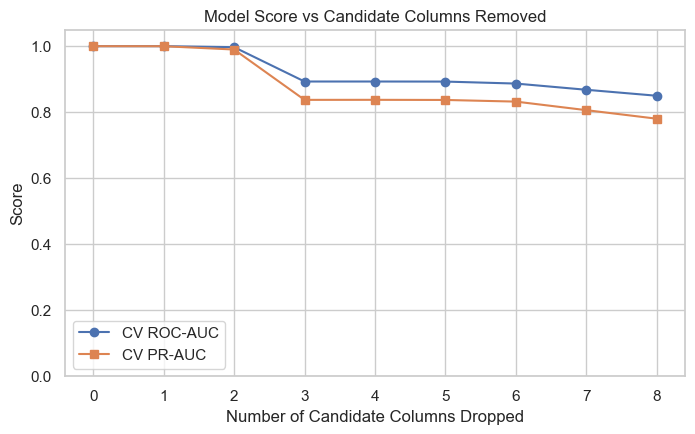

In [9]:
plt.figure(figsize=(8, 4.5))
plt.plot(
    ablation_df["n_cols_dropped"],
    ablation_df["CV ROC-AUC"],
    marker="o",
    label="CV ROC-AUC"
)
plt.plot(
    ablation_df["n_cols_dropped"],
    ablation_df["CV PR-AUC"],
    marker="s",
    label="CV PR-AUC"
)
plt.xlabel("Number of Candidate Columns Dropped")
plt.ylabel("Score")
plt.title("Model Score vs Candidate Columns Removed")
plt.ylim(0, 1.05)
plt.legend()
plt.show()


## 10. Leakage Correction

Based on the ablation analysis, these four columns are removed:

- `rate_of_interest`
- `Interest_rate_spread`
- `Upfront_charges`
- `property_value`

The other candidate columns, including **`term`**, remain in the model.


In [10]:
leakage_cols = [
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges",
    "property_value"
]

X_train = X_train_raw.drop(columns=leakage_cols)
X_test = X_test_raw.drop(columns=leakage_cols)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Leakage columns removed.")
print("Final number of features:", X_train.shape[1])
print("Is term still present?", "term" in X_train.columns)


Leakage columns removed.
Final number of features: 27
Is term still present? True


## 11. Remaining Missing Values

In [11]:
remaining_missing = X_train.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

display(pd.DataFrame({
    "missing_count": remaining_missing,
    "missing_pct": (remaining_missing / len(X_train) * 100).round(2)
}))


,missing_count,missing_pct
dtir1,19254,16.19
LTV,12001,10.09
income,7355,6.18
loan_limit,2696,2.27
approv_in_adv,715,0.60
age,156,0.13
submission_of_application,156,0.13
loan_purpose,103,0.09
Neg_ammortization,96,0.08
term,33,0.03


## 12. Quick EDA — Numeric Correlation

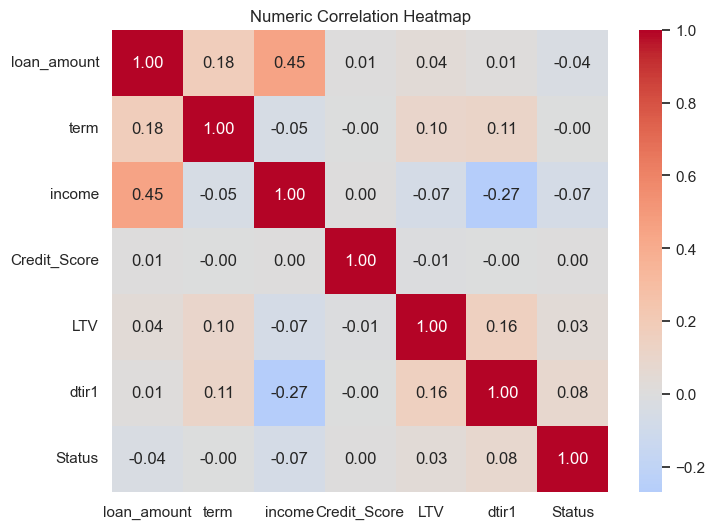

In [12]:
corr_df = X_train[numeric_features].copy()
corr_df[TARGET] = y_train.values

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Correlation Heatmap")
plt.show()


## 13. Term EDA — One Plot Only

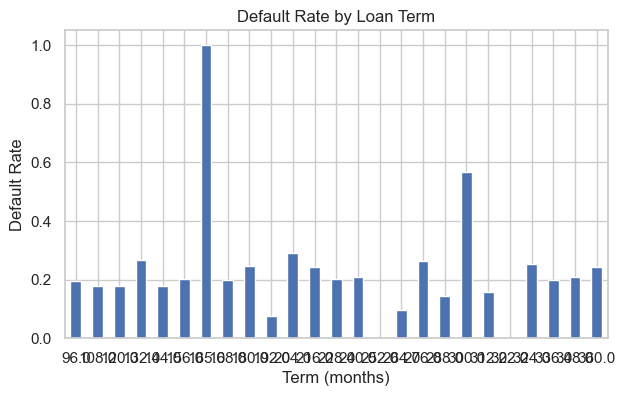

In [13]:
term_default_rate = (
    X_train.assign(Status=y_train.values)
    .groupby("term")["Status"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(7, 4))
term_default_rate.plot(kind="bar")
plt.title("Default Rate by Loan Term")
plt.xlabel("Term (months)")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()


## 14. Preprocessing and Model Builders

In [14]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor():
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ]), categorical_features)
    ])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "LightGBM"
]

strategies = [
    "Class weighting",
    "SMOTE",
    "SMOTE + class weighting"
]

def make_model(name, weighted):
    if name == "Logistic Regression":
        return LogisticRegression(
            max_iter=1000,
            class_weight="balanced" if weighted else None
        )

    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced" if weighted else None,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    if name == "XGBoost":
        return XGBClassifier(
            n_estimators=250,
            max_depth=6,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight if weighted else 1,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    if name == "LightGBM":
        return LGBMClassifier(
            n_estimators=250,
            max_depth=6,
            learning_rate=0.05,
            class_weight="balanced" if weighted else None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )

def make_pipeline(model_name, strategy):
    weighted = strategy in ["Class weighting", "SMOTE + class weighting"]
    use_smote = strategy in ["SMOTE", "SMOTE + class weighting"]

    steps = [("preprocess", make_preprocessor())]

    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))

    steps.append(("model", make_model(model_name, weighted)))

    if use_smote:
        return ImbPipeline(steps)

    return Pipeline(steps)

print("Models:", models)
print("Strategies:", strategies)


Models: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']
Strategies: ['Class weighting', 'SMOTE', 'SMOTE + class weighting']


## 15. Model and Imbalance Strategy Selection

In [15]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = []

for model_name in models:
    for strategy in strategies:
        print("Running:", model_name, "|", strategy)

        pipe = make_pipeline(model_name, strategy)

        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring=["roc_auc", "average_precision"],
            n_jobs=-1
        )

        results.append({
            "Model": model_name,
            "Strategy": strategy,
            "CV ROC-AUC": scores["test_roc_auc"].mean(),
            "CV PR-AUC": scores["test_average_precision"].mean()
        })

cv_results = pd.DataFrame(results).sort_values(
    ["CV PR-AUC", "CV ROC-AUC"],
    ascending=False
).reset_index(drop=True)

display(cv_results.round(4))

best_model_name = cv_results.loc[0, "Model"]
best_strategy = cv_results.loc[0, "Strategy"]

print("Best model:", best_model_name)
print("Best strategy:", best_strategy)


Running: Logistic Regression | Class weighting
Running: Logistic Regression | SMOTE
Running: Logistic Regression | SMOTE + class weighting
Running: Random Forest | Class weighting
Running: Random Forest | SMOTE
Running: Random Forest | SMOTE + class weighting
Running: XGBoost | Class weighting
Running: XGBoost | SMOTE
Running: XGBoost | SMOTE + class weighting
Running: LightGBM | Class weighting
Running: LightGBM | SMOTE
Running: LightGBM | SMOTE + class weighting


,Model,Strategy,CV ROC-AUC,CV PR-AUC
0,XGBoost,SMOTE,0.8933,0.8376
1,LightGBM,SMOTE,0.8931,0.8374
2,LightGBM,SMOTE + class weighting,0.8931,0.8374
3,XGBoost,Class weighting,0.8933,0.8374
4,LightGBM,Class weighting,0.8932,0.8371
5,XGBoost,SMOTE + class weighting,0.8933,0.8367
6,Random Forest,Class weighting,0.8847,0.8226
7,Random Forest,SMOTE,0.8814,0.8185
8,Random Forest,SMOTE + class weighting,0.8814,0.8185
9,Logistic Regression,Class weighting,0.8181,0.7308


Best model: XGBoost
Best strategy: SMOTE


## 16. Threshold Tuning

In [16]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

threshold_pipe = make_pipeline(best_model_name, best_strategy)
threshold_pipe.fit(X_fit, y_fit)

val_prob = threshold_pipe.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_prob)

f1_values = (
    2 * precision[:-1] * recall[:-1] /
    (precision[:-1] + recall[:-1] + 1e-12)
)

best_index = np.argmax(f1_values)
best_threshold = float(thresholds[best_index])

print("Best threshold:", round(best_threshold, 3))
print("Validation precision:", round(precision[best_index], 3))
print("Validation recall:", round(recall[best_index], 3))
print("Validation F1:", round(f1_values[best_index], 3))


Best threshold: 0.341
Validation precision: 0.85
Validation recall: 0.656
Validation F1: 0.74


## 17. Precision, Recall and F1 vs Threshold

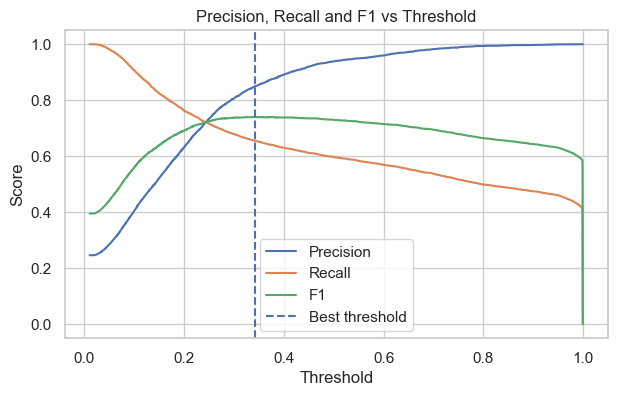

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_values, label="F1")
plt.axvline(best_threshold, linestyle="--", label="Best threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold")
plt.legend()
plt.show()


## 18. Final Test Evaluation

In [18]:
best_pipe = make_pipeline(best_model_name, best_strategy)
best_pipe.fit(X_train, y_train)

test_prob = best_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

metrics = {
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "PR-AUC": average_precision_score(y_test, test_prob),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "Accuracy": (test_pred == y_test).mean()
}

print(classification_report(y_test, test_pred, digits=3, zero_division=0))

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")


              precision    recall  f1-score   support

           0      0.902     0.962     0.931     22406
           1      0.856     0.681     0.759      7328

    accuracy                          0.893     29734
   macro avg      0.879     0.822     0.845     29734
weighted avg      0.891     0.893     0.889     29734

ROC-AUC: 0.8962
PR-AUC: 0.8450
Precision: 0.8558
Recall: 0.6812
F1: 0.7586
Accuracy: 0.8932


## 19. Confusion Matrix and Precision-Recall Curve

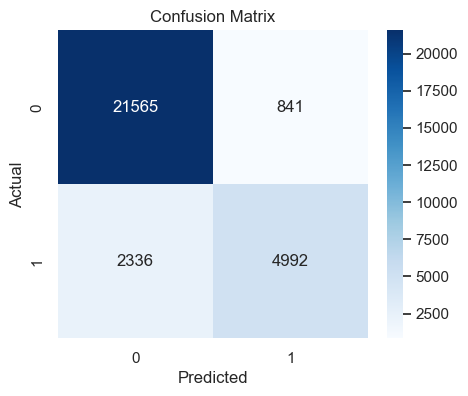

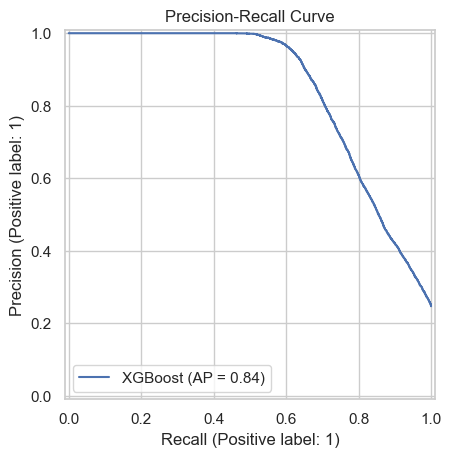

In [19]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_prob,
    name=best_model_name
)
plt.title("Precision-Recall Curve")
plt.show()


## 20. ROC Curve

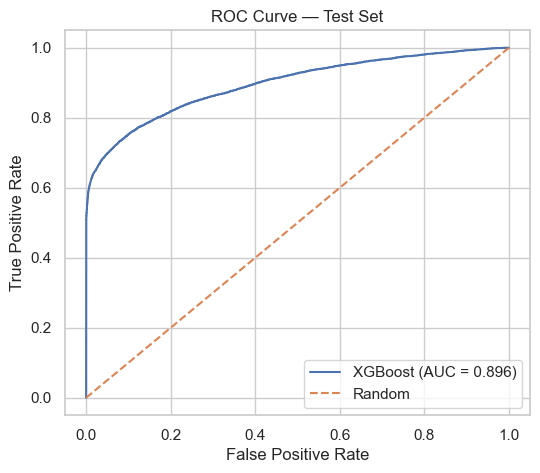

In [20]:
fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = roc_auc_score(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.show()


## 21. Calibration Curve

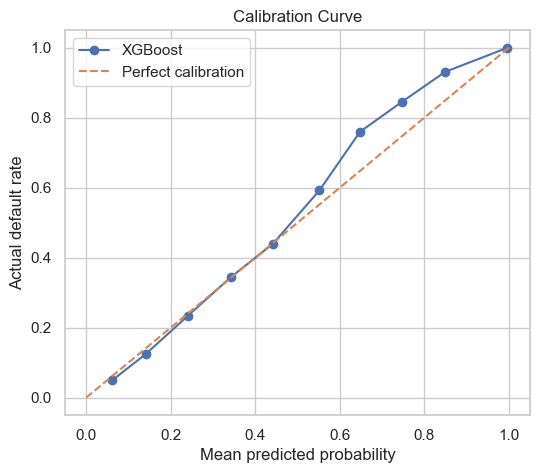

In [21]:
prob_true, prob_pred = calibration_curve(
    y_test,
    test_prob,
    n_bins=10
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label=best_model_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual default rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()


## 22. Feature Importance

,feature,importance
46,cat__credit_type_EQUI,0.440835
49,cat__co-applicant_credit_type_EXP,0.132417
13,cat__approv_in_adv_pre,0.067013
59,cat__Region_North,0.050300
57,cat__submission_of_application_not_inst,0.041738
27,cat__Neg_ammortization_neg_amm,0.030069
31,cat__lump_sum_payment_lpsm,0.025562
15,cat__loan_type_type2,0.022247
45,cat__credit_type_CRIF,0.015140
53,cat__age_55-64,0.014141


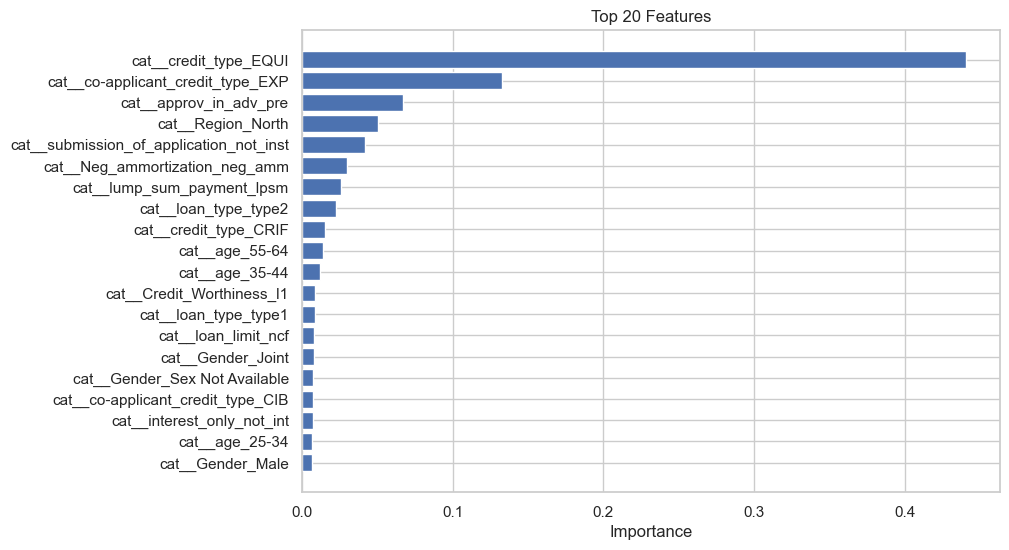

In [22]:
preprocessor = best_pipe.named_steps["preprocess"]
model = best_pipe.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importance = model.feature_importances_
else:
    importance = np.abs(model.coef_[0])

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

top_features = importance_df.head(20).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top 20 Features")
plt.show()


## 23. SHAP Explainability

In [23]:
import shap

X_test_transformed = preprocessor.transform(X_test)

n_shap = min(300, len(X_test_transformed))
rng = np.random.RandomState(RANDOM_STATE)
indices = rng.choice(len(X_test_transformed), n_shap, replace=False)

X_shap = X_test_transformed[indices]

if hasattr(model, "feature_importances_"):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background = preprocessor.transform(
        X_train.sample(min(300, len(X_train)), random_state=RANDOM_STATE)
    )
    explainer = shap.LinearExplainer(model, background)
    shap_values = explainer.shap_values(X_shap)

print("SHAP shape:", np.asarray(shap_values).shape)


SHAP shape: (300, 65)


## 24. Global SHAP Importance

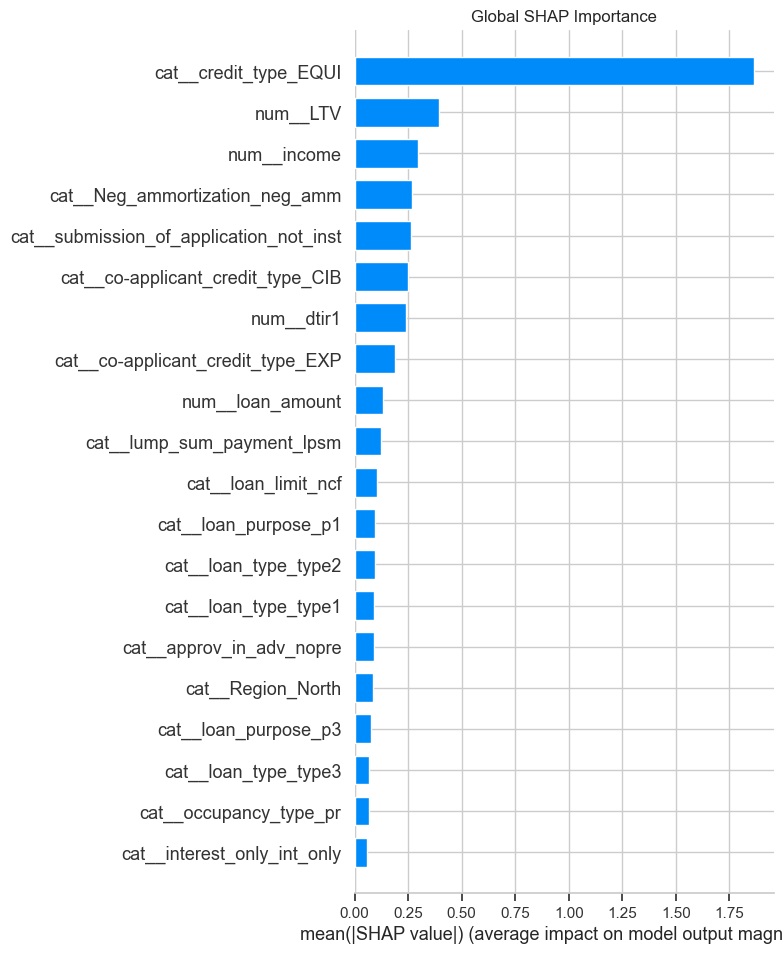

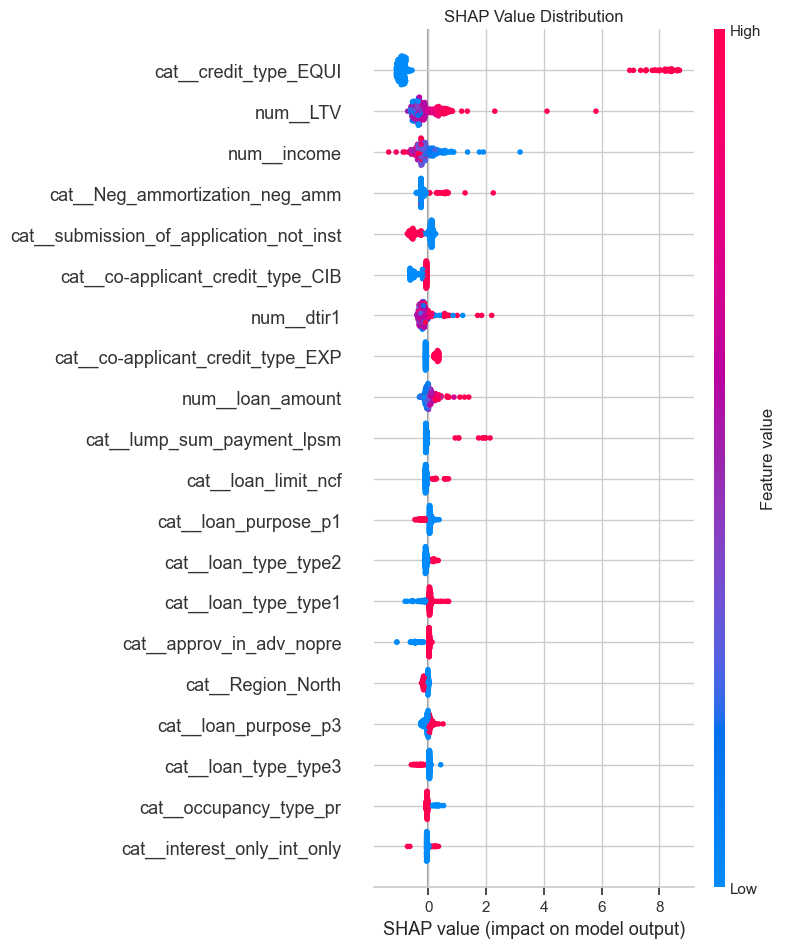

In [24]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("Global SHAP Importance")
plt.show()

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Value Distribution")
plt.show()


## 25. SHAP Dependence Plots

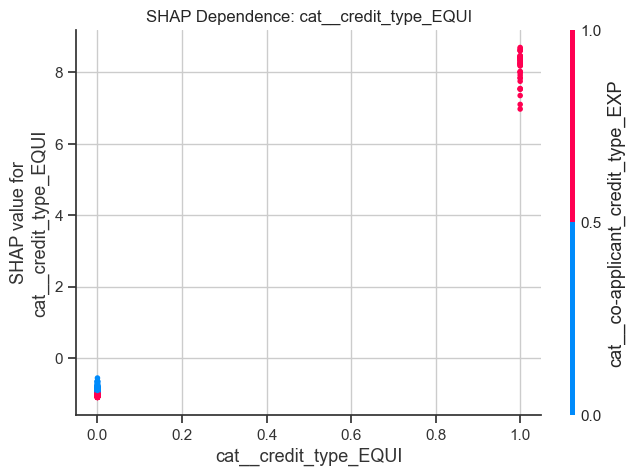

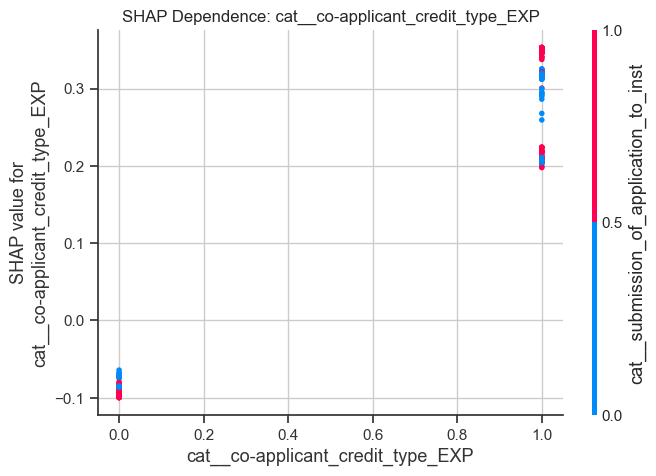

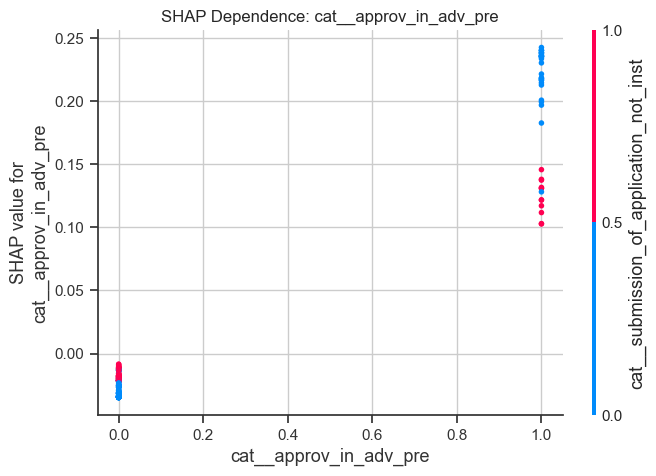

In [25]:
top3 = importance_df.head(3)["feature"].tolist()

for feature in top3:
    index = list(feature_names).index(feature)

    shap.dependence_plot(
        index,
        shap_values,
        X_shap,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"SHAP Dependence: {feature}")
    plt.show()


## 26. SHAP Waterfall — Highest and Lowest Risk

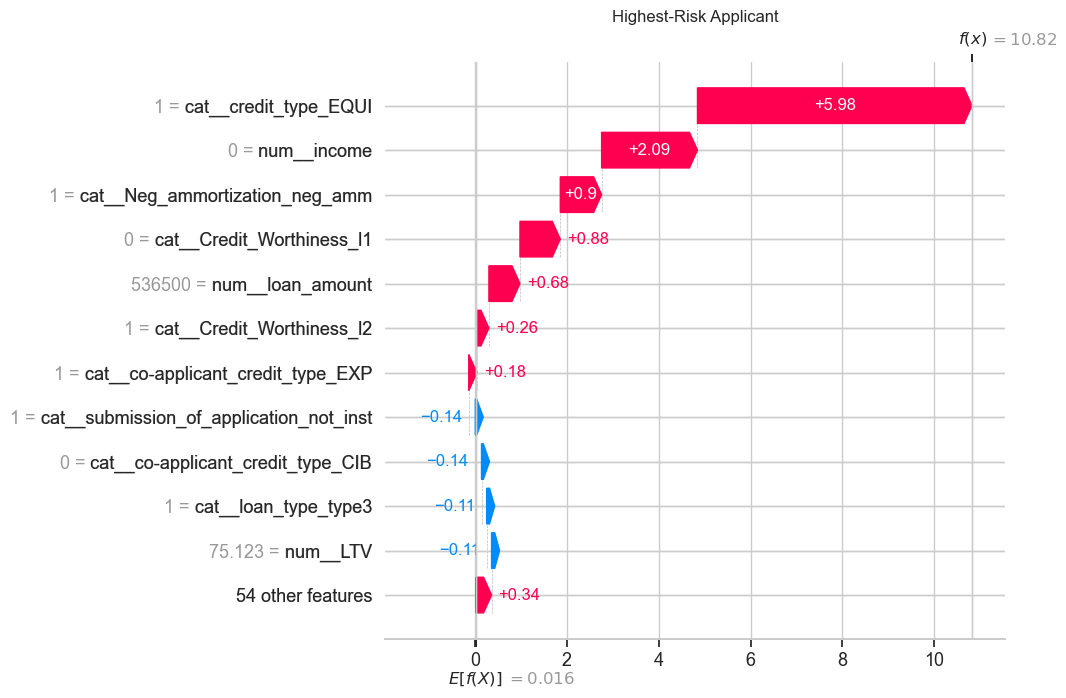

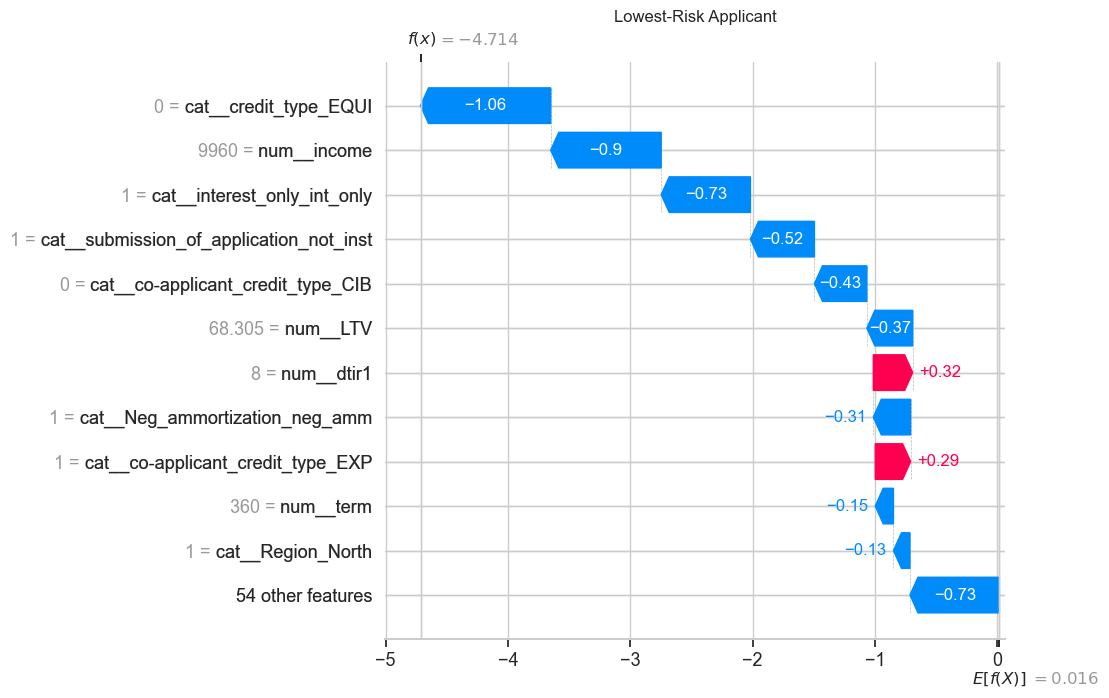

In [26]:
expected_value = explainer.expected_value

if isinstance(expected_value, np.ndarray):
    expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]

high_idx = np.argmax(test_prob)
low_idx = np.argmin(test_prob)

X_test_one = preprocessor.transform(X_test.iloc[[high_idx]])
X_test_low = preprocessor.transform(X_test.iloc[[low_idx]])

high_values = explainer.shap_values(X_test_one)
low_values = explainer.shap_values(X_test_low)

if isinstance(high_values, list):
    high_values = high_values[1]
if isinstance(low_values, list):
    low_values = low_values[1]

high_exp = shap.Explanation(
    values=high_values[0],
    base_values=expected_value,
    data=X_test_one[0],
    feature_names=feature_names
)

low_exp = shap.Explanation(
    values=low_values[0],
    base_values=expected_value,
    data=X_test_low[0],
    feature_names=feature_names
)

shap.plots.waterfall(high_exp, max_display=12, show=False)
plt.title("Highest-Risk Applicant")
plt.show()

shap.plots.waterfall(low_exp, max_display=12, show=False)
plt.title("Lowest-Risk Applicant")
plt.show()


## 27. Risk Bands

,applicants,actual_default_rate,avg_predicted_probability,share_of_test_set
risk_band,,,,
Low risk,23791,0.096969,0.109787,0.800128
Medium risk,1600,0.485625,0.459844,0.053810
High risk,4343,0.977205,0.958422,0.146062


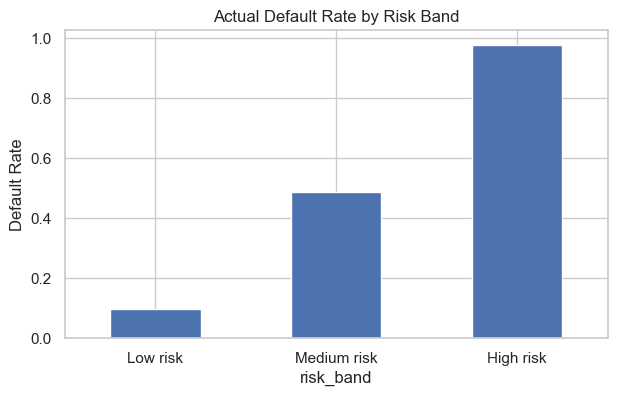

In [27]:
risk_df = X_test.copy()
risk_df["actual_default"] = y_test.values
risk_df["predicted_probability"] = test_prob

def risk_band(p):
    if p >= 0.66:
        return "High risk"
    elif p >= 0.33:
        return "Medium risk"
    return "Low risk"

risk_df["risk_band"] = risk_df["predicted_probability"].apply(risk_band)

band_order = ["Low risk", "Medium risk", "High risk"]

band_summary = (
    risk_df.groupby("risk_band")
    .agg(
        applicants=("actual_default", "size"),
        actual_default_rate=("actual_default", "mean"),
        avg_predicted_probability=("predicted_probability", "mean")
    )
    .reindex(band_order)
)

band_summary["share_of_test_set"] = (
    band_summary["applicants"] /
    band_summary["applicants"].sum()
)

display(band_summary)

plt.figure(figsize=(7, 4))
band_summary["actual_default_rate"].plot(kind="bar")
plt.title("Actual Default Rate by Risk Band")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()


## 28. Segment Analysis

In [28]:
base_rate = y_test.mean()
segment_rows = []

for col in categorical_features:
    grouped = risk_df.groupby(col)["actual_default"].agg(["mean", "size"])

    for level, row in grouped.iterrows():
        if row["size"] < max(20, int(0.01 * len(risk_df))):
            continue

        segment_rows.append({
            "feature": col,
            "segment": str(level),
            "n": int(row["size"]),
            "default_rate": row["mean"],
            "lift_vs_base": row["mean"] / base_rate
        })

segment_df = pd.DataFrame(segment_rows)
segment_df = segment_df.sort_values("lift_vs_base", ascending=False)

print("Base default rate:", round(base_rate, 4))
display(segment_df.head(15))


Base default rate: 0.2465


,feature,segment,n,default_rate,lift_vs_base
34,credit_type,EQUI,3140,1.000000,4.057587
24,lump_sum_payment,lpsm,728,0.810440,3.288429
20,Neg_ammortization,neg_amm,2977,0.448438,1.819576
9,loan_type,type2,4200,0.346190,1.404698
18,business_or_commercial,b/c,4200,0.346190,1.404698
1,loan_limit,ncf,1978,0.334681,1.357999
12,loan_purpose,p2,629,0.330684,1.341778
16,Credit_Worthiness,l2,1282,0.322933,1.310329
37,co-applicant_credit_type,EXP,14961,0.309739,1.256792
43,age,>74,1430,0.304895,1.237139


In [29]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_pipe, "artifacts/loan_default_model.joblib")

with open("artifacts/model_info.txt", "w") as f:
    f.write(f"Model: {best_model_name}\n")
    f.write(f"Strategy: {best_strategy}\n")
    f.write(f"Threshold: {best_threshold:.4f}\n")
    for name, value in metrics.items():
        f.write(f"{name}: {value:.4f}\n")

cv_results.to_csv("artifacts/cv_results.csv", index=False)
importance_df.to_csv("artifacts/feature_importance.csv", index=False)

print("Artifacts saved in the 'artifacts' folder.")

Artifacts saved in the 'artifacts' folder.
